## 1) Configuración y librerías



In [22]:
# =============================================================================
# 2) Paths base y helpers de EDA (Colab + Drive)
# =============================================================================
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Configuración general
warnings.filterwarnings("ignore")
np.random.seed(42)

# -------------------------------------------------------------------------
#  Google Drive
# -------------------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

# -------------------------------------------------------------------------
# Utilidad: display compatible con Jupyter
# -------------------------------------------------------------------------
try:
    from IPython.display import display
except Exception:
    def display(obj):
        try:
            print(obj.head(10))
        except Exception:
            print(obj)

# -------------------------------------------------------------------------
# Librerías de Machine Learning
# -------------------------------------------------------------------------
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

# Extras
import joblib


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Helpers varios


In [24]:
# =============================================================================
# Funciones utilitarias generales
# =============================================================================
def _es_jupyter():
    return ("ipykernel" in sys.modules) or ("JPY_PARENT_PID" in os.environ)

def mostrar_y_guardar(path_png: str, dpi: int = 120):
    """Guardo figura y la muestro si estoy en ambiente interactivo."""
    plt.tight_layout()
    plt.savefig(path_png, dpi=dpi, bbox_inches="tight")
    if _es_jupyter():
        plt.show()
    plt.close()

def grafico_barh_top(series_valores: pd.Series, titulo: str, path_png: str, top: int = 15):
    """Barh con Top-k importancias/valores ordenados ascendente (se ven del mayor arriba)."""
    top_series = series_valores.sort_values(ascending=True).tail(top)
    plt.figure(figsize=(8, 5))
    top_series.plot(kind="barh")
    plt.title(titulo); plt.xlabel("Valor")
    mostrar_y_guardar(path_png)

## 3) Carga de datos y helpers para el EDA
Todo lo que crea carpetas, carga CSVs, hace winsorización, paneles de nulos/ceros/outliers, guardado de diccionario, relevamiento de fuentes).

In [12]:
# =============================================================================
# 2) Paths base y helpers de EDA
# =============================================================================
# Ruta base: carpeta de tu proyecto en Drive
CARPETA_BASE =  "/content/drive/MyDrive/TrabajoFinalGrupoE"

# Carpeta de datos (la única que debe existir antes de correr el notebook)
CARPETA_DATOS = os.path.join(CARPETA_BASE, "Datos")

# Carpetas de salida (se crean automáticamente)
CARPETA_ARTEFACTOS = os.path.join(CARPETA_BASE, "artefactos")
CARPETA_EDA = os.path.join(CARPETA_ARTEFACTOS, "eda")
CARPETA_FIG = os.path.join(CARPETA_ARTEFACTOS, "figuras")

for carpeta in [CARPETA_ARTEFACTOS, CARPETA_EDA, CARPETA_FIG]:
    os.makedirs(carpeta, exist_ok=True)

def cargar_csv(nombre: str) -> pd.DataFrame:
    """Carga un CSV desde la carpeta de datos con chequeo de existencia."""
    ruta = os.path.join(CARPETA_DATOS, nombre)
    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró {ruta}. Verificá que los CSV estén ahí.")
    return pd.read_csv(ruta)

def winsorizar_en_sitio(df: pd.DataFrame, columna: str, p: float=0.99) -> None:
    """Winsorizo tope superior al percentil p (in-place) para estabilizar outliers."""
    df[columna] = pd.to_numeric(df[columna], errors="coerce").astype(float)
    pctl = df[columna].quantile(p)
    df[columna] = np.clip(df[columna], None, pctl)

def panel_nulos(df: pd.DataFrame, nombre: str, mostrar_top: int = 10):
    res = (df.isna().sum().sort_values(ascending=False).rename("nulos").to_frame())
    res["porcentaje"] = res["nulos"]/len(df)
    res.to_csv(os.path.join(CARPETA_EDA, f"nulos_{nombre}.csv"), encoding="utf-8")
    print(f"Top nulos — {nombre}"); display(res.head(mostrar_top))
    return res

def panel_ceros(df: pd.DataFrame, nombre: str, columnas: list | None = None, mostrar_top: int = 10):
    if columnas is None:
        columnas = df.select_dtypes(include=[np.number]).columns.tolist()
    filas = []; n = len(df)
    for c in columnas:
        try:
            serie = pd.to_numeric(df[c], errors="coerce")
            cnt = int((serie == 0).sum()); filas.append([c, cnt, cnt/n])
        except Exception:
            pass
    out_df = pd.DataFrame(filas, columns=["columna","ceros","porcentaje"]).sort_values("ceros", ascending=False)
    out_df.to_csv(os.path.join(CARPETA_EDA, f"ceros_{nombre}.csv"), index=False, encoding="utf-8")
    print(f"Ceros — {nombre}"); display(out_df.head(mostrar_top))
    return out_df

def panel_outliers(df: pd.DataFrame, cols_num: list, nombre: str):
    filas = []
    for c in cols_num:
        serie = pd.to_numeric(df[c], errors="coerce")
        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
        fuera = ((serie < lim_inf) | (serie > lim_sup)).sum()
        p99 = serie.quantile(0.99)
        filas.append([c, float(serie.isna().mean()), float(q1), float(q3), float(iqr),
                      float(lim_inf), float(lim_sup), int(fuera), float(p99)])
    out_df = pd.DataFrame(filas, columns=["variable","porc_nulos","q1","q3","iqr","lim_inf","lim_sup","conteo_outliers_iqr","p99"])
    out_df.to_csv(os.path.join(CARPETA_EDA, f"outliers_{nombre}.csv"), index=False, encoding="utf-8")
    print(f"Outliers (IQR) — {nombre}"); display(out_df);
    return out_df

def guardar_diccionario_minimo(mostrar=True):
    """Documento simple de definición de variables finales del modelo."""
    descripcion = {
        "tiempo_preparacion_dias":"días entre aprobación y despacho",
        "dias_prometidos_desde_envio":"días entre despacho y fecha estimada",
        "total_precio":"suma de price por orden (winsor p99)",
        "total_flete":"suma de freight_value por orden (winsor p99)",
        "relacion_flete":"total_flete / total_precio",
        "pago_cuotas":"número de cuotas (máximo por orden)",
        "tipo_pago":"modalidad de pago (OHE)",
        "hora_compra":"hora del día (0–23)",
        "dia_semana":"día de semana (0=lunes)",
        "mes_compra":"mes de compra (1–12)",
        "categoria_principal":"categoría moda por orden",
        "mala_resena":"1 si review_score ≤ 2",
        "seller_mala_tasa_hist":"tasa histórica malas reseñas seller (hasta D-1)",
        "seller_mala_conteo_hist":"conteo reseñas previas seller",
        "cliente_mala_tasa_hist":"tasa histórica malas reseñas cliente (hasta D-1)",
        "cliente_mala_conteo_hist":"conteo reseñas previas cliente",
        "cliente_ordenes_previas":"órdenes previas del cliente (hasta D-1)",
        "cliente_recencia_dias":"días desde compra previa del cliente",
        "geo_dist_km":"distancia Haversine cliente–seller (km)",
        "inter_UF":"1 si customer_state != seller_state"
    }
    df_dict = pd.DataFrame(list(descripcion.items()), columns=["variable","descripcion"])
    df_dict.to_csv(os.path.join(CARPETA_EDA, "diccionario_minimo.csv"), index=False, encoding="utf-8")
    if mostrar:
        print("Diccionario mínimo de variables (modelo):")
        display(df_dict)
    return df_dict

def relevamiento_fuentes_info(tablas_dict: dict):
    """Resumen de fuentes (nº de filas/columnas y claves principales)."""
    filas = []; claves = {
        "ordenes":"order_id","items_orden":"order_id, product_id, seller_id",
        "pagos_orden":"order_id","reviews_orden":"order_id","productos":"product_id",
        "vendedores":"seller_id","clientes":"customer_id","geoloc":"geolocation_zip_code_prefix"
    }
    for nombre, df in tablas_dict.items():
        filas.append([nombre, len(df), df.shape[1], claves.get(nombre, "")])
    df_rel = pd.DataFrame(filas, columns=["tabla","filas","columnas","claves"])
    df_rel.to_csv(os.path.join(CARPETA_EDA, "relevamiento_fuentes.csv"), index=False, encoding="utf-8")
    print("Relevamiento de fuentes (tamaño por tabla):"); display(df_rel);
    return df_rel

def _haversine_km(lat1, lon1, lat2, lon2):
    """Distancia Haversine en km entre (lat1,lon1) y (lat2,lon2)."""
    R = 6371.0
    lat1 = np.radians(pd.to_numeric(lat1, errors="coerce"))
    lon1 = np.radians(pd.to_numeric(lon1, errors="coerce"))
    lat2 = np.radians(pd.to_numeric(lat2, errors="coerce"))
    lon2 = np.radians(pd.to_numeric(lon2, errors="coerce"))
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return R * (2*np.arcsin(np.sqrt(a)))

# =============================================================================
# 3) Carga de datasets Olist y chequeos básicos
# =============================================================================
ordenes         = cargar_csv("olist_orders_dataset.csv")
items_orden     = cargar_csv("olist_order_items_dataset.csv")
pagos_orden     = cargar_csv("olist_order_payments_dataset.csv")
reviews_orden   = cargar_csv("olist_order_reviews_dataset.csv")
productos       = cargar_csv("olist_products_dataset.csv")
vendedores      = cargar_csv("olist_sellers_dataset.csv")
clientes        = cargar_csv("olist_customers_dataset.csv")
geoloc          = cargar_csv("olist_geolocation_dataset.csv")

# Normalizo ZIPs a string para merge con geoloc
geoloc["geolocation_zip_code_prefix"] = geoloc["geolocation_zip_code_prefix"].astype(str)
clientes["customer_zip_code_prefix"]   = clientes["customer_zip_code_prefix"].astype(str)
vendedores["seller_zip_code_prefix"]   = vendedores["seller_zip_code_prefix"].astype(str)

# Geo promedio por ZIP
geo_zip = (geoloc.groupby("geolocation_zip_code_prefix", as_index=False)
           .agg(lat=("geolocation_lat","mean"), lng=("geolocation_lng","mean")))

# Relevamiento rápido de fuentes (para el informe/EDA)
relevamiento_fuentes_info({
    "ordenes":ordenes, "items_orden":items_orden, "pagos_orden":pagos_orden,
    "reviews_orden":reviews_orden, "productos":productos, "vendedores":vendedores,
    "clientes":clientes, "geoloc":geoloc
})


Relevamiento de fuentes (tamaño por tabla):


,tabla,filas,columnas,claves
0,ordenes,99441,8,order_id
1,items_orden,112650,7,"order_id, product_id, seller_id"
2,pagos_orden,103886,5,order_id
3,reviews_orden,99224,7,order_id
4,productos,32951,9,product_id
5,vendedores,3095,4,seller_id
6,clientes,99441,5,customer_id
7,geoloc,1000163,5,geolocation_zip_code_prefix


,tabla,filas,columnas,claves
0,ordenes,99441,8,order_id
1,items_orden,112650,7,"order_id, product_id, seller_id"
2,pagos_orden,103886,5,order_id
3,reviews_orden,99224,7,order_id
4,productos,32951,9,product_id
5,vendedores,3095,4,seller_id
6,clientes,99441,5,customer_id
7,geoloc,1000163,5,geolocation_zip_code_prefix


## 4) Split temporal train / valid / test

División de los datos en conjuntos de entrenamiento, validación y prueba respetando la estructura temporal.

In [13]:

# =============================================================================
# 4) Limpieza, feature engineering y vista maestra por orden
# =============================================================================
# Parseo fechas clave
col_fechas = ["order_purchase_timestamp","order_approved_at",
              "order_delivered_carrier_date","order_delivered_customer_date",
              "order_estimated_delivery_date"]
for c in col_fechas:
    ordenes[c] = pd.to_datetime(ordenes[c], errors="coerce")

# Me quedo con despachadas (tengo fecha de envío)
ordenes_desp = ordenes[ordenes["order_delivered_carrier_date"].notna()].copy()

# Agrego categoría producto y winsorizo price/freight por orden
items_con_cat = items_orden.merge(
    productos[["product_id","product_category_name"]], on="product_id", how="left"
).copy()
for col in ["price","freight_value"]:
    winsorizar_en_sitio(items_con_cat, col, 0.99)

ag_items = (items_con_cat.groupby("order_id")
    .agg(total_precio=("price","sum"),
         total_flete=("freight_value","sum"),
         cantidad_items=("order_item_id","count"),
         categoria_principal=("product_category_name",
                              lambda x: x.mode().iat[0] if len(x.mode()) else np.nan))
    .reset_index())

ag_pagos = (pagos_orden.groupby("order_id")
    .agg(pago_total=("payment_value","sum"),
         pago_cuotas=("payment_installments","max"),
         tipo_pago=("payment_type", lambda x: x.mode().iat[0] if len(x.mode()) else np.nan))
    .reset_index())

# Etiqueta: mala reseña (score <= 2)
etiquetas = reviews_orden[["order_id","review_score"]].copy()
etiquetas["mala_resena"] = (etiquetas["review_score"] <= 2).astype(int)

# Tomo primer vendedor por orden (para armar features seller-state, etc.)
primer_vendedor = items_orden[["order_id","seller_id"]].drop_duplicates("order_id")

# Vista maestra (mergea todo lo necesario)
df = (ordenes_desp
      .merge(ag_items, on="order_id", how="left")
      .merge(ag_pagos, on="order_id", how="left")
      .merge(etiquetas[["order_id","mala_resena"]], on="order_id", how="left")
      .merge(clientes[["customer_id","customer_state","customer_zip_code_prefix"]], on="customer_id", how="left")
      .merge(primer_vendedor, on="order_id", how="left")
      .merge(vendedores[["seller_id","seller_state","seller_zip_code_prefix"]], on="seller_id", how="left"))

# Join geo aproximado por ZIP (cliente/seller) y distancia Haversine
geo_c = geo_zip.rename(columns={"geolocation_zip_code_prefix":"customer_zip_code_prefix","lat":"cust_lat","lng":"cust_lng"})
geo_s = geo_zip.rename(columns={"geolocation_zip_code_prefix":"seller_zip_code_prefix","lat":"sell_lat","lng":"sell_lng"})
df = (df.merge(geo_c, on="customer_zip_code_prefix", how="left")
        .merge(geo_s, on="seller_zip_code_prefix", how="left"))

df["geo_dist_km"] = _haversine_km(df["cust_lat"], df["cust_lng"], df["sell_lat"], df["sell_lng"])
p99_geo = df["geo_dist_km"].quantile(0.99)
df["geo_dist_km"] = np.where(df["geo_dist_km"].notna() & (df["geo_dist_km"]>p99_geo), p99_geo, df["geo_dist_km"])

# Tiempos y calendarios
df["tiempo_preparacion_dias"] = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.total_seconds()/86400
df["dias_prometidos_desde_envio"] = (df["order_estimated_delivery_date"] - df["order_delivered_carrier_date"]).dt.total_seconds()/86400
df["relacion_flete"] = df["total_flete"] / (df["total_precio"] + 1e-6)
df["hora_compra"]  = df["order_purchase_timestamp"].dt.hour
df["dia_semana"]   = df["order_purchase_timestamp"].dt.dayofweek
df["mes_compra"]   = df["order_purchase_timestamp"].dt.month
df["categoria_principal"] = df["categoria_principal"].fillna("desconocida")
df["inter_UF"] = (df["customer_state"] != df["seller_state"]).astype(int)

# Tasas históricas por seller y por cliente (orden temporal para no fugar)
def _tasas_historicas(df_hist: pd.DataFrame, col_grupo: str, col_evento: str,
                      col_fecha: str, prefijo: str) -> pd.DataFrame:
    df_hist = df_hist.sort_values(col_fecha).copy()
    g = df_hist.groupby(col_grupo, sort=False)
    conteo_prev = g[col_evento].cumcount()
    suma_prev = g[col_evento].cumsum() - df_hist[col_evento]
    tasa_prev = np.where(conteo_prev > 0, suma_prev / conteo_prev, np.nan)
    df_hist[f"{prefijo}_tasa_hist"] = tasa_prev
    df_hist[f"{prefijo}_conteo_hist"] = conteo_prev
    return df_hist

df = df.sort_values("order_delivered_carrier_date").copy()
if "seller_id" in df.columns:
    df = _tasas_historicas(df, "seller_id", "mala_resena", "order_delivered_carrier_date", "seller_mala")
if "customer_id" in df.columns:
    df = _tasas_historicas(df, "customer_id", "mala_resena", "order_delivered_carrier_date", "cliente_mala")

# Recencia y frecuencia por cliente
df["cliente_ordenes_previas"] = df.groupby("customer_id").cumcount()
df["cliente_ultima_compra_previa"] = df.groupby("customer_id")["order_purchase_timestamp"].shift(1)
df["cliente_recencia_dias"] = (df["order_purchase_timestamp"] - df["cliente_ultima_compra_previa"]).dt.total_seconds()/86400.0
df["cliente_recencia_dias"] = df["cliente_recencia_dias"].replace([np.inf, -np.inf], np.nan)




## 5) Preprocesamiento y nombres de features

Construcción del pipeline de transformación de variables y definición de la lista final de features.

In [14]:
# =============================================================================
# 5) Split temporal train / valid / test
# =============================================================================
datos = df[df["mala_resena"].notna()].copy()
print(f"\nFilas etiquetadas: {len(datos):,} | % mala_resena: {datos['mala_resena'].mean():.3f}")

corte_train = pd.to_datetime("2017-09-30")
fin_valid   = pd.to_datetime("2017-12-31")
fin_test    = pd.to_datetime("2018-06-30")

train = datos[datos["order_purchase_timestamp"] <= corte_train].copy()
valid = datos[(datos["order_purchase_timestamp"] > corte_train) &
              (datos["order_purchase_timestamp"] <= fin_valid)].copy()
test  = datos[(datos["order_purchase_timestamp"] > fin_valid) &
              (datos["order_purchase_timestamp"] <= fin_test)].copy()

OBJETIVO = "mala_resena"
vars_num = ["total_precio","total_flete","cantidad_items","relacion_flete",
            "pago_total","pago_cuotas","tiempo_preparacion_dias","dias_prometidos_desde_envio",
            "hora_compra","dia_semana","mes_compra",
            "seller_mala_tasa_hist","seller_mala_conteo_hist",
            "cliente_mala_tasa_hist","cliente_mala_conteo_hist",
            "cliente_ordenes_previas","cliente_recencia_dias",
            "geo_dist_km","inter_UF"]
vars_num  = [v for v in vars_num if v in datos.columns]
vars_cat = ["tipo_pago","categoria_principal","customer_state","seller_state"]
vars_cat = [v for v in vars_cat if v in datos.columns]

VARS = vars_num + vars_cat
X_tr, y_tr = train[VARS], train[OBJETIVO].astype(int)
X_va, y_va = valid[VARS], valid[OBJETIVO].astype(int)
X_te, y_te = test[VARS],  test[OBJETIVO].astype(int)




Filas etiquetadas: 97,468 | % mala_resena: 0.135


## 6) Preprocesamiento y nombres de features

Construcción del pipeline de transformación de variables y definición de la lista final de features.

In [15]:
# =============================================================================
# 6) Preprocesamiento (ColumnTransformer) y nombres de features
# =============================================================================

pipe_num = Pipeline([("imp", SimpleImputer(strategy="median"))])
pipe_cat = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore"))])
pre_arboles = ColumnTransformer([("num", pipe_num, vars_num), ("cat", pipe_cat, vars_cat)])
pre_arboles.fit(X_tr)

try:
    ohe = pre_arboles.named_transformers_["cat"].named_steps["ohe"]
    nombres_cat = list(ohe.get_feature_names_out(vars_cat))
except Exception:
    nombres_cat = []
nombres_vars = vars_num + nombres_cat

def evaluar(modelo, X: pd.DataFrame, y: pd.Series, etiqueta: str, fraccion: float=0.30):
    """Métricas claves + recall/precisión en top-k% (priorización operativa)."""
    proba = modelo.predict_proba(X)[:,1]
    proba = np.asarray(proba, dtype=float)
    proba = np.where(np.isfinite(proba), proba, 0.0)
    roc  = roc_auc_score(y, proba)
    ap   = average_precision_score(y, proba)
    k = int(math.ceil(fraccion * len(proba)))
    idx_top = np.argsort(proba)[::-1][:k]
    pos_top = int(y.iloc[idx_top].sum())
    recall_k = pos_top / int(y.sum()) if int(y.sum())>0 else 0.0
    prec_k = pos_top / k if k>0 else 0.0
    print(f"[{etiqueta}] ROC-AUC: {roc:.3f} | PR-AUC: {ap:.3f} | "
          f"Recall@{int(fraccion*100)}%: {recall_k:.3f} | Prec@{int(fraccion*100)}%: {prec_k:.3f} "
          f"(positivos en top {k}: {pos_top} de {int(y.sum())})")
    return roc, ap, recall_k, prec_k, proba


## 7) Modelado con XGBoost

Entrenamiento, ajuste y evaluación preliminar del modelo XGBoost en los conjuntos de validación/test.

[INFO] XGBoost detectado: 3.0.5
[AVISO] XGBoost sin callbacks en esta versión. Entreno sin early stopping.
[TRAIN XGB] ROC-AUC: 0.931 | PR-AUC: 0.656 | Recall@30%: 0.922 | Prec@30%: 0.348 (positivos en top 8007: 2790 de 3025)
[VALID XGB] ROC-AUC: 0.630 | PR-AUC: 0.263 | Recall@30%: 0.456 | Prec@30%: 0.227 (positivos en top 5231: 1190 de 2609)
[TEST  XGB] ROC-AUC: 0.601 | PR-AUC: 0.235 | Recall@30%: 0.420 | Prec@30%: 0.214 (positivos en top 12194: 2610 de 6212)


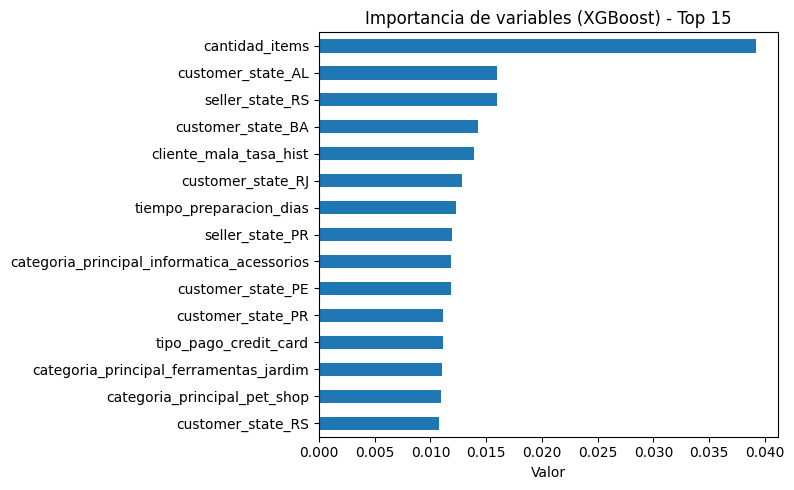

Top 20 importancias XGB:


,importancia
cantidad_items,0.039232
customer_state_AL,0.015966
seller_state_RS,0.015965
customer_state_BA,0.014227
cliente_mala_tasa_hist,0.013895
customer_state_RJ,0.012878
tiempo_preparacion_dias,0.012336
seller_state_PR,0.011900
categoria_principal_informatica_acessorios,0.011847
customer_state_PE,0.011808



[Calibración] XGB (isotónica) — métricas:
[VALID XGB_cal] ROC-AUC: 0.633 | PR-AUC: 0.257 | Recall@30%: 0.457 | Prec@30%: 0.228 (positivos en top 5231: 1193 de 2609)
[TEST  XGB_cal] ROC-AUC: 0.600 | PR-AUC: 0.226 | Recall@30%: 0.420 | Prec@30%: 0.214 (positivos en top 12194: 2609 de 6212)


In [28]:
# =============================================================================
# 7) XGBoost (con fallback sin callbacks) + export de importancias
# =============================================================================
proba_xgb_te = None
proba_xgb_te_cal = None

class _ModelWrapper:
    """Wrapper simple para unificar predict_proba usando un preprocesador externo."""
    def __init__(self, pre, clf):
        self.pre=pre; self.clf=clf
    def predict_proba(self, X):
        Xt = self.pre.transform(X);
        return self.clf.predict_proba(Xt)

try:
    import xgboost
    from xgboost import XGBClassifier
    print(f"[INFO] XGBoost detectado: {xgboost.__version__}")
except Exception as e:
    import traceback;
    print("[ERROR] No se pudo importar XGBoost.");
    traceback.print_exc();
    XGBClassifier=None

if XGBClassifier is not None:
    try:
        pre_xgb = clone(pre_arboles); pre_xgb.fit(X_tr)
        Xt_tr = pre_xgb.transform(X_tr); Xt_va = pre_xgb.transform(X_va); Xt_te = pre_xgb.transform(X_te)
        ratio = (y_tr == 0).sum() / max(1, (y_tr == 1).sum())

        xgb_clf = XGBClassifier(
            n_estimators=1200,  # moderado (sin early stopping)
            max_depth=4, learning_rate=0.05,
            min_child_weight=5, subsample=0.7, colsample_bytree=0.7,
            reg_lambda=2.0, reg_alpha=0.5,
            objective="binary:logistic", eval_metric="aucpr",
            tree_method="hist", random_state=42, scale_pos_weight=ratio
        )

        used_callbacks = False
        try:
            callbacks = [xgboost.callback.EarlyStopping(
                rounds=100, save_best=True, maximize=True,
                data_name="validation_0", metric_name="aucpr"
            )]
            xgb_clf.fit(Xt_tr, y_tr, eval_set=[(Xt_va, y_va)], callbacks=callbacks, verbose=False)
            used_callbacks = True
        except TypeError:
            # Fallback: sin callbacks (mantengo regularización fuerte)
            print("[AVISO] XGBoost sin callbacks en esta versión. Entreno sin early stopping.")
            xgb_clf.fit(Xt_tr, y_tr, eval_set=[(Xt_va, y_va)], verbose=False)

        modelo_xgb = _ModelWrapper(pre_xgb, xgb_clf)
        _, _, _, _, _ = evaluar(modelo_xgb, X_tr, y_tr, "TRAIN XGB", 0.30)
        _, _, _, _, _ = evaluar(modelo_xgb, X_va, y_va, "VALID XGB", 0.30)
        _, _, _, _, proba_xgb_te = evaluar(modelo_xgb, X_te, y_te, "TEST  XGB", 0.30)

        # Importancias y guardados
        try:
            nombres_cat_x = list(pre_xgb.named_transformers_["cat"].named_steps["ohe"].get_feature_names_out(vars_cat)) if vars_cat else []
            nombres_vars_x = vars_num + nombres_cat_x
            imp_xgb = pd.Series(xgb_clf.feature_importances_, index=nombres_vars_x)
            imp_xgb.sort_values(ascending=False).to_csv(os.path.join(CARPETA_ARTEFACTOS, "importancias_xgb.csv"), encoding="utf-8")
            grafico_barh_top(imp_xgb, "Importancia de variables (XGBoost) - Top 15",
                             os.path.join(CARPETA_FIG, "importancias_top15_xgb.png"))
            print("Top 20 importancias XGB:");
            display(imp_xgb.sort_values(ascending=False).head(20).to_frame("importancia"))
        except Exception:
            import traceback;
            print("[AVISO] No se pudieron exportar importancias XGB:");
            traceback.print_exc()

        joblib.dump(pre_xgb, os.path.join(CARPETA_ARTEFACTOS, "preprocesador_xgb.joblib"))
        joblib.dump(xgb_clf, os.path.join(CARPETA_ARTEFACTOS, "modelo_xgboost.joblib"))

        # Calibración isotónica usando VALID (sin fuga)
        try:
            from sklearn.isotonic import IsotonicRegression
            p_val = xgb_clf.predict_proba(Xt_va)[:,1]
            iso = IsotonicRegression(out_of_bounds="clip"); iso.fit(p_val, y_va)

            class _ModelWrapperIso:
                def __init__(self, pre, clf, iso): self.pre=pre; self.clf=clf; self.iso=iso
                def predict_proba(self, X):
                    Xt = self.pre.transform(X); p = self.clf.predict_proba(Xt)[:,1]
                    p_cal = self.iso.transform(p); return np.vstack([1-p_cal, p_cal]).T

            modelo_xgb_cal = _ModelWrapperIso(pre_xgb, xgb_clf, iso)
            print("\n[Calibración] XGB (isotónica) — métricas:")
            _, _, _, _, _ = evaluar(modelo_xgb_cal, X_va, y_va, "VALID XGB_cal", 0.30)
            _, _, _, _, proba_xgb_te_cal = evaluar(modelo_xgb_cal, X_te, y_te, "TEST  XGB_cal", 0.30)
            joblib.dump(iso, os.path.join(CARPETA_ARTEFACTOS, "calibrador_isotonico_xgb.joblib"))
        except Exception:
            import traceback;
            print("[AVISO] Falló la calibración XGB:");
            traceback.print_exc()

    except Exception:
        import traceback;
        print("[ERROR] Falló el bloque XGBoost (fit/eval).");
        traceback.print_exc()

## 8) Modelado con LightGBM

Entrenamiento, ajuste y evaluación preliminar del modelo LightGBM en los conjuntos de validación/test.

[LightGBM] [Info] Number of positive: 3025, number of negative: 23665
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2505
[LightGBM] [Info] Number of data points in the train set: 26690, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[128]	valid_0's average_precision: 0.297702	valid_0's binary_logloss: 0.616496
[TRAIN LGBM] ROC-AUC: 0.778 | PR-AUC: 0.314 | Recall@30%: 0.647 | Prec@30%: 0.245 (positivos en top 8007: 1958 de 3025)
[VALID LGBM] ROC-AUC: 0.663 | PR-AUC: 0.298 | Recall@30%: 0.501 | Prec@30%: 0.250 (positivos en top 5231: 1306 de 2609)
[TEST  LGBM] ROC-AUC: 0.650 | PR-AUC: 0.275 | Recall@30%: 0.482 | Prec@30%: 0.245 (positivos 

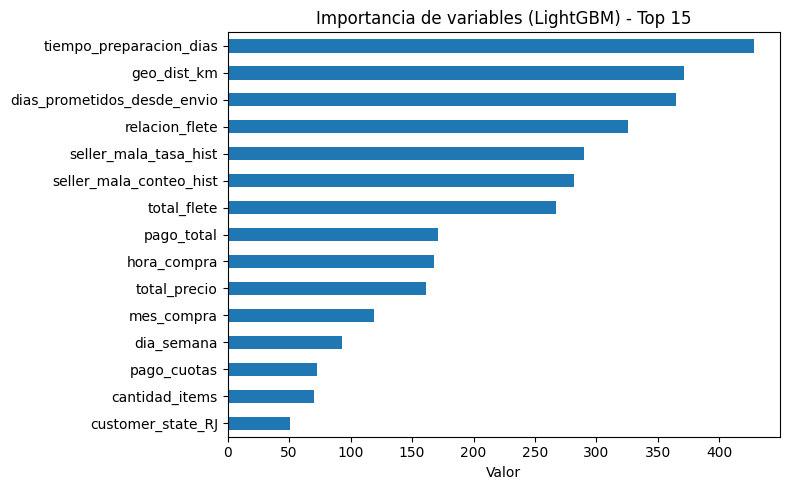

In [17]:
# =============================================================================
# 8) LightGBM en Pipeline (eval_set PREPROCESADO) + calibración
# =============================================================================
proba_lgb_te = None
proba_lgb_te_cal = None
try:
    from lightgbm import LGBMClassifier
    # Preprocesar VALID para pasarlo como eval_set ya transformado
    X_va_pre = pre_arboles.transform(X_va)

    modelo_lgb = Pipeline([
        ("pre", pre_arboles),
        ("clf", LGBMClassifier(
            n_estimators=3000, learning_rate=0.03,
            num_leaves=31, max_depth=-1, min_child_samples=100,
            subsample=0.7, colsample_bytree=0.7,
            reg_lambda=1.0, reg_alpha=0.5,
            random_state=42, class_weight="balanced",
            objective="binary", boosting_type="gbdt"
        ))
    ])

    # Intento callbacks si existen en la versión instalada
    used_lgb_callbacks = False
    try:
        from lightgbm import early_stopping, log_evaluation
        callbacks = [early_stopping(stopping_rounds=200), log_evaluation(0)]
        modelo_lgb.fit(
            X_tr, y_tr,
            clf__eval_set=[(X_va_pre, y_va)],  # <<< eval_set ya preprocesado
            clf__eval_metric="average_precision",
            clf__callbacks=callbacks
        )
        used_lgb_callbacks = True
    except Exception as _:
        print("[AVISO] LightGBM sin callbacks en esta versión. Entreno sin early stopping.")
        modelo_lgb.fit(X_tr, y_tr)

    # Métricas
    _, _, _, _, _ = evaluar(modelo_lgb, X_tr, y_tr, "TRAIN LGBM", 0.30)
    _, _, _, _, _ = evaluar(modelo_lgb, X_va, y_va, "VALID LGBM", 0.30)
    _, _, _, _, proba_lgb_te = evaluar(modelo_lgb, X_te, y_te, "TEST  LGBM", 0.30)

    # Importancias y guardados
    try:
        imp_lgb = pd.Series(modelo_lgb.named_steps["clf"].feature_importances_, index=nombres_vars)
        imp_lgb.sort_values(ascending=False).to_csv(os.path.join(CARPETA_ARTEFACTOS, "importancias_lgbm.csv"), encoding="utf-8")
        grafico_barh_top(imp_lgb, "Importancia de variables (LightGBM) - Top 15",
                         os.path.join(CARPETA_FIG, "importancias_top15_lgbm.png"))
        print("Top 20 importancias LGBM:");
        display(imp_lgb.sort_values(ascending=False).head(20).to_frame("importancia"))
    except Exception as e:
        print("[AVISO] No se pudieron exportar importancias LGBM:", e)

    joblib.dump(modelo_lgb, os.path.join(CARPETA_ARTEFACTOS, "modelo_lightgbm.joblib"))

    # Calibración isotónica con VALID (cv='prefit' para no reentrenar y evitar fuga)
    lgb_cal = CalibratedClassifierCV(modelo_lgb, method="isotonic", cv="prefit")
    lgb_cal.fit(X_va, y_va)
    print("\n[Calibración] LGBM (isotónica) — métricas:")
    _, _, _, _, _ = evaluar(lgb_cal, X_va, y_va, "VALID LGBM_cal", 0.30)
    _, _, _, _, proba_lgb_te_cal = evaluar(lgb_cal, X_te, y_te, "TEST  LGBM_cal", 0.30)
    joblib.dump(lgb_cal, os.path.join(CARPETA_ARTEFACTOS, "modelo_lightgbm_calibrado.joblib"))

except Exception as e:
    print("\n[AVISO] LightGBM no disponible. Si falta instalar: conda install -c conda-forge lightgbm")
    import traceback; traceback.print_exc()


## 9) Ranking combinado de importancias

Comparación de las importancias de variables entre modelos para identificar los principales predictores.

[AVISO] No se pudo generar ranking combinado de importancias: name 'sys' is not defined


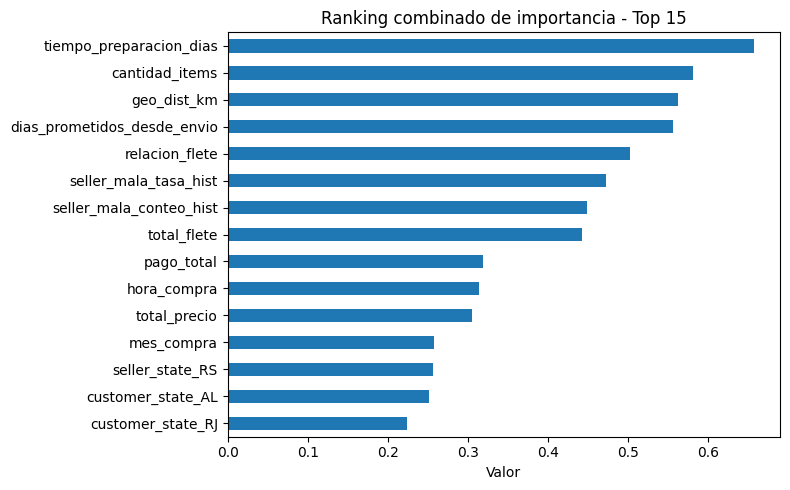

In [18]:
# =============================================================================
# 9) Ranking combinado de importancias (XGB + LGBM)
# =============================================================================
try:
    tablas_imp = []
    rx = os.path.join(CARPETA_ARTEFACTOS, "importancias_xgb.csv")
    rl = os.path.join(CARPETA_ARTEFACTOS, "importancias_lgbm.csv")
    if os.path.exists(rx):
        ix = pd.read_csv(rx, index_col=0, header=None, names=["importancia"]); tablas_imp.append(ix["importancia"])
    if os.path.exists(rl):
        il = pd.read_csv(rl, index_col=0, header=None, names=["importancia"]); tablas_imp.append(il["importancia"])
    if tablas_imp:
        imp_df = pd.concat(tablas_imp, axis=1)
        imp_norm = imp_df.apply(lambda s: (s - s.min())/(s.max() - s.min() + 1e-9), axis=0)
        imp_prom = imp_norm.mean(axis=1).sort_values(ascending=False)
        imp_prom.to_csv(os.path.join(CARPETA_ARTEFACTOS, "ranking_importancias_promedio.csv"), encoding="utf-8")
        grafico_barh_top(imp_prom, "Ranking combinado de importancia - Top 15",
                         os.path.join(CARPETA_FIG, "importancias_top15_promedio.png"))
        print("Ranking combinado de importancia (Top 20):")
        display(imp_prom.head(20).to_frame("importancia_normalizada_promedio"))
except Exception as e:
    print("[AVISO] No se pudo generar ranking combinado de importancias:", e)



## 10) Curvas PR y ROC en TEST

Evaluación del rendimiento en el conjunto de prueba mediante curvas de precisión-recall y ROC.

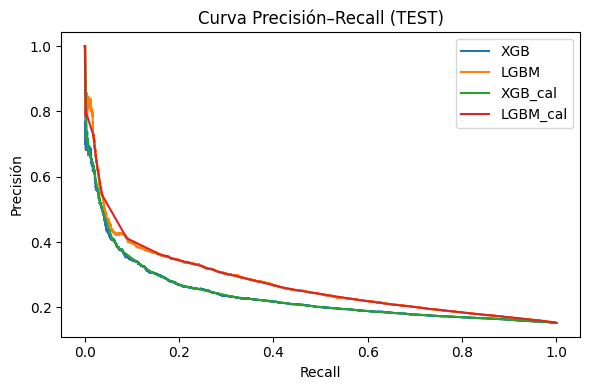

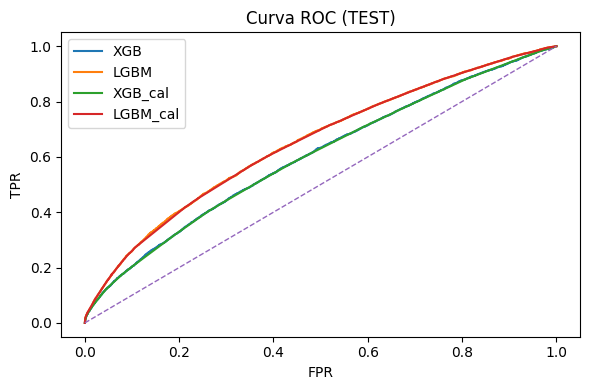

In [25]:
# =============================================================================
# 10) Curvas PR y ROC en TEST (todas las variantes disponibles)
# =============================================================================
if any(v is not None for v in [proba_xgb_te, proba_lgb_te, proba_xgb_te_cal, proba_lgb_te_cal]):
    plt.figure(figsize=(6,4))
    if proba_xgb_te is not None:
        p, r, _ = precision_recall_curve(y_te, proba_xgb_te); plt.plot(r, p, label="XGB")
    if proba_lgb_te is not None:
        p, r, _ = precision_recall_curve(y_te, proba_lgb_te); plt.plot(r, p, label="LGBM")
    if proba_xgb_te_cal is not None:
        p, r, _ = precision_recall_curve(y_te, proba_xgb_te_cal); plt.plot(r, p, label="XGB_cal")
    if proba_lgb_te_cal is not None:
        p, r, _ = precision_recall_curve(y_te, proba_lgb_te_cal); plt.plot(r, p, label="LGBM_cal")
    plt.title("Curva Precisión–Recall (TEST)"); plt.xlabel("Recall"); plt.ylabel("Precisión"); plt.legend()
    mostrar_y_guardar(os.path.join(CARPETA_FIG, "curva_pr_test.png"))

    plt.figure(figsize=(6,4))
    if proba_xgb_te is not None:
        fpr, tpr, _ = roc_curve(y_te, proba_xgb_te); plt.plot(fpr, tpr, label="XGB")
    if proba_lgb_te is not None:
        fpr, tpr, _ = roc_curve(y_te, proba_lgb_te); plt.plot(fpr, tpr, label="LGBM")
    if proba_xgb_te_cal is not None:
        fpr, tpr, _ = roc_curve(y_te, proba_xgb_te_cal); plt.plot(fpr, tpr, label="XGB_cal")
    if proba_lgb_te_cal is not None:
        fpr, tpr, _ = roc_curve(y_te, proba_lgb_te_cal); plt.plot(fpr, tpr, label="LGBM_cal")
    plt.plot([0,1],[0,1],'--', linewidth=1)
    plt.title("Curva ROC (TEST)"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
    mostrar_y_guardar(os.path.join(CARPETA_FIG, "curva_roc_test.png"))

## 11) Export de probabilidades en TEST + Top-N priorizado

Generación de probabilidades de churn en test y armado de un ranking priorizado de clientes.

In [26]:
# =============================================================================
# 11) Export de probabilidades en TEST + Top-N priorizado
# =============================================================================
df_out = pd.DataFrame({"order_id": test["order_id"].values, "es_mala_resena": y_te.values})
if proba_xgb_te is not None:      df_out["proba_xgb"] = proba_xgb_te
if proba_lgb_te is not None:      df_out["proba_lgbm"] = proba_lgb_te
if proba_xgb_te_cal is not None:  df_out["proba_xgb_cal"] = proba_xgb_te_cal
if proba_lgb_te_cal is not None:  df_out["proba_lgbm_cal"] = proba_lgb_te_cal
df_out.to_csv(os.path.join(CARPETA_ARTEFACTOS, "prob_test_xgb_lgbm.csv"), index=False, encoding="utf-8")

TOP_N = 5000
df_rank = df_out.copy()
col_proba = None
for c in ["proba_xgb_cal", "proba_lgbm_cal", "proba_xgb", "proba_lgbm"]:
    if c in df_rank.columns:
        col_proba = c; break
if col_proba is None:
    print("[AVISO] No hay columna de probabilidades para priorizar Top-N.")
else:
    df_rank = df_rank.sort_values(col_proba, ascending=False).head(TOP_N)
    path_topn = os.path.join(CARPETA_ARTEFACTOS, f"top_{TOP_N}_priorizados.csv")
    df_rank.to_csv(path_topn, index=False, encoding="utf-8")
    print(f"[OK] Export Top-{TOP_N} priorizados → {path_topn}")

print("\n[OK] EDA, modelos, métricas e importancias exportados en:", CARPETA_ARTEFACTOS)
print("    - Tablas EDA:", CARPETA_EDA)
print("    - Figuras:", CARPETA_FIG)

[OK] Export Top-5000 priorizados → /content/drive/MyDrive/TrabajoFinalGrupoE/artefactos/top_5000_priorizados.csv

[OK] EDA, modelos, métricas e importancias exportados en: /content/drive/MyDrive/TrabajoFinalGrupoE/artefactos
    - Tablas EDA: /content/drive/MyDrive/TrabajoFinalGrupoE/artefactos/eda
    - Figuras: /content/drive/MyDrive/TrabajoFinalGrupoE/artefactos/figuras


## 12) Interpretabilidad con SHAP

Análisis de interpretabilidad del modelo mediante valores SHAP para entender el impacto de cada feature.

[INFO] Modelo elegido para SHAP: LGBM (PR-AUC TEST=0.2748)
[OK] SHAP summary guardado en /content/drive/MyDrive/TrabajoFinalGrupoE/artefactos/figuras/shap_summary.png


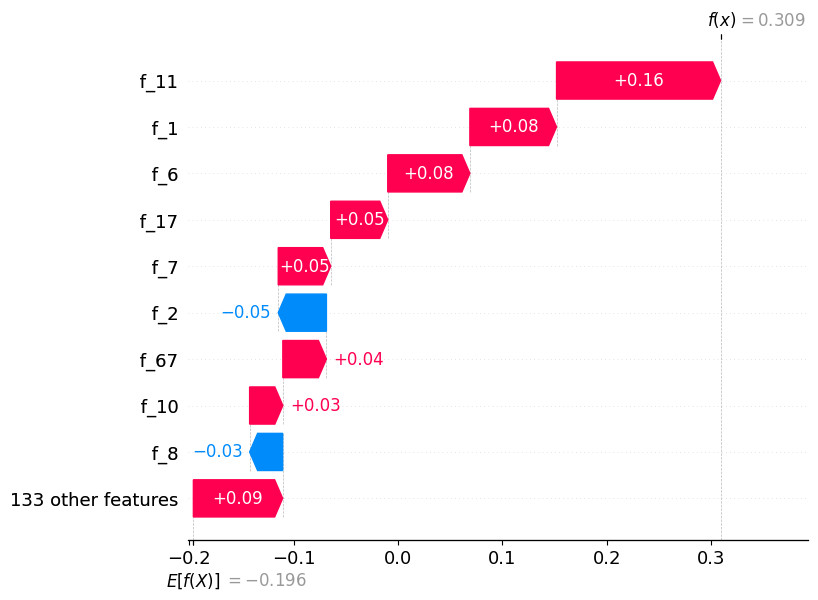

[OK] SHAP waterfall (local) guardado en /content/drive/MyDrive/TrabajoFinalGrupoE/artefactos/figuras/shap_waterfall.png


In [27]:
# =============================================================================
# 12) INTERPRETABILIDAD CON SHAP — Selección automática del MEJOR modelo
#      (usa PR-AUC en TEST; preferencia: LGBM_cal > LGBM > XGB_cal > XGB)
# =============================================================================
try:
    import shap
except ImportError:
    print("[AVISO] No se encontró 'shap'. Instalalo con: pip install shap")
else:
    try:
        # --- 12.1: Armo lista de candidatos con sus proba en TEST ---
        candidatos = []  # (label, proba_test, getter_fn)

        def _getter_lgb_cal():
            base = lgb_cal.base_estimator  # Pipeline(pre, clf)
            return base.named_steps["clf"], base.named_steps["pre"], (nombres_vars[:] if 'nombres_vars' in locals() else None)

        def _getter_lgb():
            return (modelo_lgb.named_steps["clf"],
                    modelo_lgb.named_steps["pre"],
                    (nombres_vars[:] if 'nombres_vars' in locals() else None))

        def _getter_xgb():
            # modelo_xgb: wrapper con .clf (xgb) y .pre (CT)
            modelo_arbol = modelo_xgb.clf
            preproc = modelo_xgb.pre
            try:
                ohe_x = preproc.named_transformers_["cat"].named_steps["ohe"]
                nombres_cat_x = list(ohe_x.get_feature_names_out(vars_cat)) if vars_cat else []
                nombres_sh = (vars_num + nombres_cat_x) if vars_num else None
            except Exception:
                nombres_sh = None
            return modelo_arbol, preproc, nombres_sh

        # Agrego candidatos (si existen probabilidades de TEST)
        if 'proba_lgb_te_cal' in locals() and proba_lgb_te_cal is not None:
            candidatos.append(("LGBM_cal", proba_lgb_te_cal, _getter_lgb_cal))
        if 'proba_lgb_te' in locals() and proba_lgb_te is not None:
            candidatos.append(("LGBM", proba_lgb_te, _getter_lgb))
        if 'proba_xgb_te_cal' in locals() and proba_xgb_te_cal is not None and 'modelo_xgb' in locals():
            # Nota: para XGB_cal explico el árbol base (igual que XGB) — la calibración es una capa encima
            candidatos.append(("XGB_cal", proba_xgb_te_cal, _getter_xgb))
        if 'proba_xgb_te' in locals() and proba_xgb_te is not None and 'modelo_xgb' in locals():
            candidatos.append(("XGB", proba_xgb_te, _getter_xgb))

        if not candidatos:
            raise RuntimeError("No hay probabilidades en TEST para seleccionar modelo para SHAP.")

        # --- 12.2: Selecciono por PR-AUC (TEST) con prioridad por tipo ---
        prioridad = {"LGBM_cal": 4, "LGBM": 3, "XGB_cal": 2, "XGB": 1}
        ap_scores = [(lbl, average_precision_score(y_te, p), get_fn) for (lbl, p, get_fn) in candidatos]
        ap_scores.sort(key=lambda t: (t[1], prioridad.get(t[0], 0)), reverse=True)
        mejor_lbl, mejor_ap, mejor_getter = ap_scores[0]
        print(f"[INFO] Modelo elegido para SHAP: {mejor_lbl} (PR-AUC TEST={mejor_ap:.4f})")

        # --- 12.3: Preparo datos transformados para el explainer ---
        modelo_arbol, preproc, nombres_shap = mejor_getter()

        # Muestra controlada para memoria
        X_sample = X_te.sample(min(2000, len(X_te)), random_state=42)

        # Misma transformación que en entrenamiento
        X_shap = preproc.transform(X_sample)
        try:
            X_shap = X_shap.toarray()  # densifico si es CSR
        except Exception:
            pass

        # --- 12.4: Armo DataFrame con nombres "string" sí o sí ---
        if nombres_shap and len(nombres_shap) == X_shap.shape[1]:
            cols = [str(c) for c in nombres_shap]          # forzar str
            X_shap_df = pd.DataFrame(X_shap, columns=cols)
        else:
            cols = [f"f_{i}" for i in range(X_shap.shape[1])]  # nombres sintéticos str
            X_shap_df = pd.DataFrame(X_shap, columns=cols)

        # --- 12.5: Explainer SHAP para modelos de árboles ---
        explainer = shap.TreeExplainer(modelo_arbol)
        shap_values = explainer.shap_values(X_shap)

        # Binario: algunas versiones devuelven lista por clase
        if isinstance(shap_values, list):
            shap_vals_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
            exp_value = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
        else:
            shap_vals_plot = shap_values
            exp_value = explainer.expected_value

        # --- 12.6: Gráficos global y local ---
        plt.figure()
        shap.summary_plot(shap_vals_plot, X_shap_df, show=False, max_display=15)
        path_summary = os.path.join(CARPETA_FIG, "shap_summary.png")
        plt.tight_layout(); plt.savefig(path_summary, dpi=120); plt.close()
        print(f"[OK] SHAP summary guardado en {path_summary}")

        idx = 0  # ejemplo local (primer fila de la muestra)
        plt.figure()
        shap.plots._waterfall.waterfall_legacy(
            exp_value,
            shap_vals_plot[idx],
            features=X_shap_df.iloc[idx, :].values,
            feature_names=list(X_shap_df.columns)   # <-- todos str
        )
        path_water = os.path.join(CARPETA_FIG, "shap_waterfall.png")
        plt.tight_layout(); plt.savefig(path_water, dpi=120); plt.close()
        print(f"[OK] SHAP waterfall (local) guardado en {path_water}")

    except Exception as e:
        import traceback
        print("[AVISO] Falló la generación de SHAP values:")
        traceback.print_exc()
